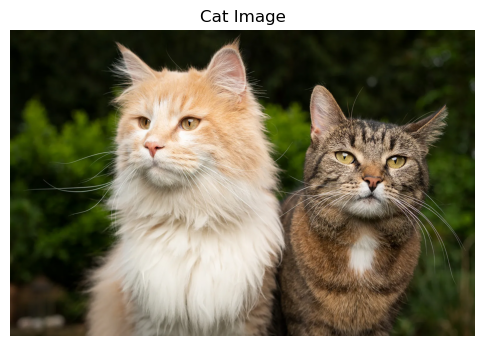

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
img = cv2.imread('cat.jpg')

# Convert BGR (OpenCV) to RGB (Matplotlib)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 5))
plt.imshow(img)
plt.title('Cat Image')
plt.axis("off")
plt.show()

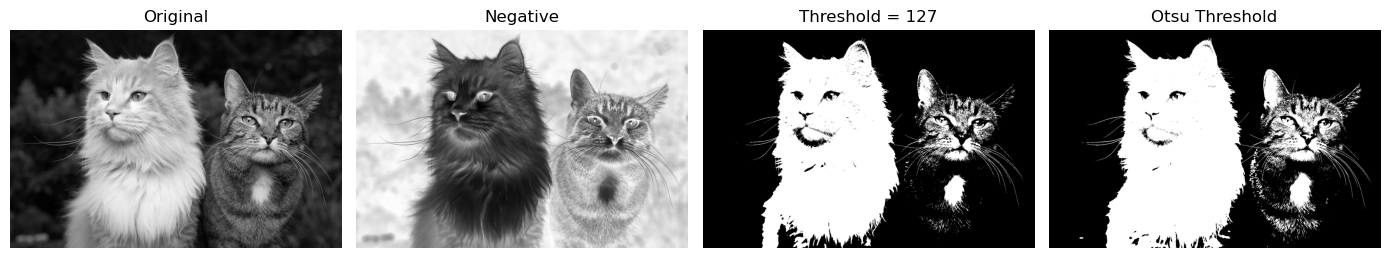

In [2]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

negative = cv2.bitwise_not(gray)

_, simple_threshold = cv2.threshold(
    gray, 127, 255, cv2.THRESH_BINARY
)

_, otsu_threshold = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

results = [gray, negative, simple_threshold, otsu_threshold]
titles = ["Original", "Negative", "Threshold = 127", "Otsu Threshold"]

plt.figure(figsize=(14, 4))

for i, result in enumerate(results):
    plt.subplot(1, 4, i + 1)
    plt.imshow(result, cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

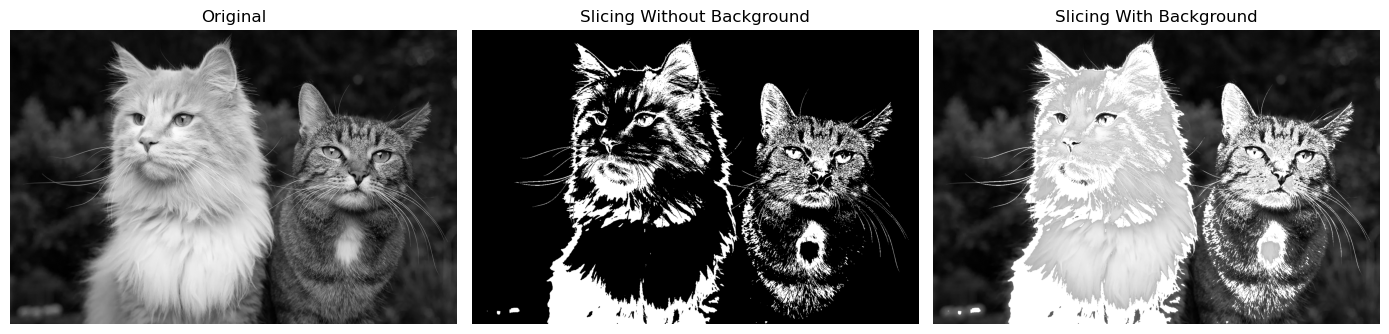

In [3]:
lower_level = 100
upper_level = 180

# Without background
without_background = np.zeros_like(gray)
mask = (gray >= lower_level) & (gray <= upper_level)
without_background[mask] = 255

# With background
with_background = gray.copy()
with_background[mask] = 255

results = [gray, without_background, with_background]
titles = [
    "Original",
    "Slicing Without Background",
    "Slicing With Background"
]

plt.figure(figsize=(14, 4))

for i, result in enumerate(results):
    plt.subplot(1, 3, i + 1)
    plt.imshow(result, cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

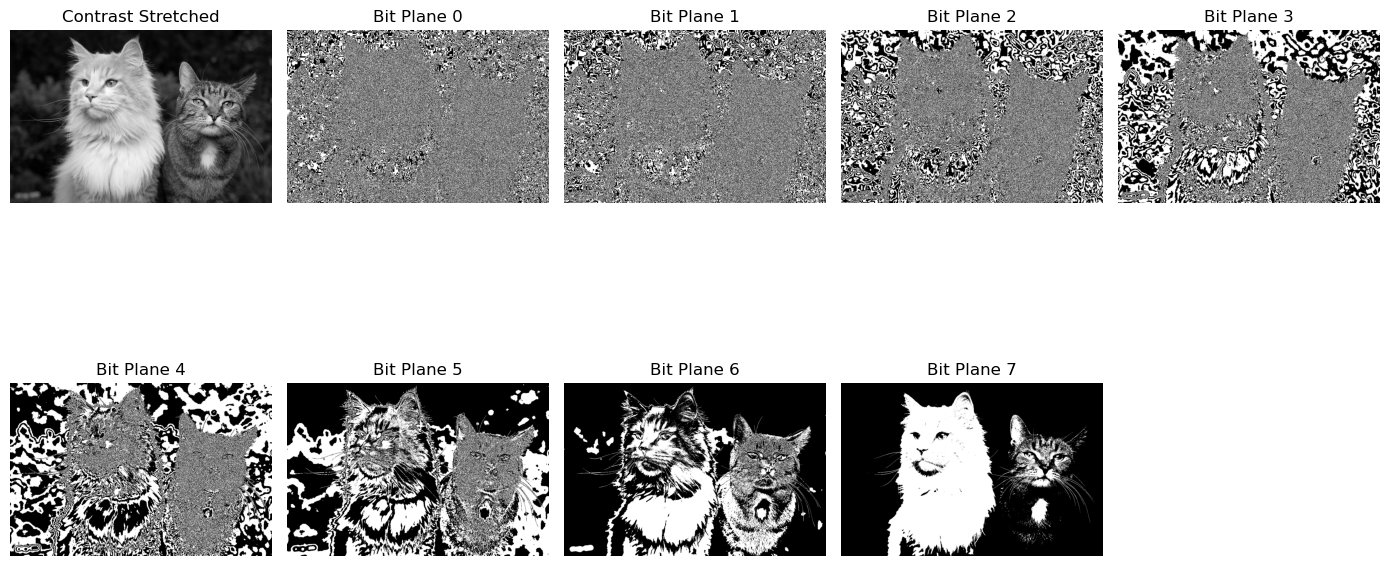

In [4]:
# Question 9 — Contrast stretching and bit-plane slicing

minimum = np.min(gray)
maximum = np.max(gray)

if maximum == minimum:
    stretched = gray.copy()
else:
    stretched = (
        (gray.astype(np.float32) - minimum) *
        255 / (maximum - minimum)
    ).astype(np.uint8)

plt.figure(figsize=(14, 8))

plt.subplot(2, 5, 1)
plt.imshow(stretched, cmap="gray")
plt.title("Contrast Stretched")
plt.axis("off")

for bit in range(8):
    bit_plane = ((gray >> bit) & 1) * 255

    plt.subplot(2, 5, bit + 2)
    plt.imshow(bit_plane, cmap="gray")
    plt.title(f"Bit Plane {bit}")
    plt.axis("off")

plt.tight_layout()
plt.show()

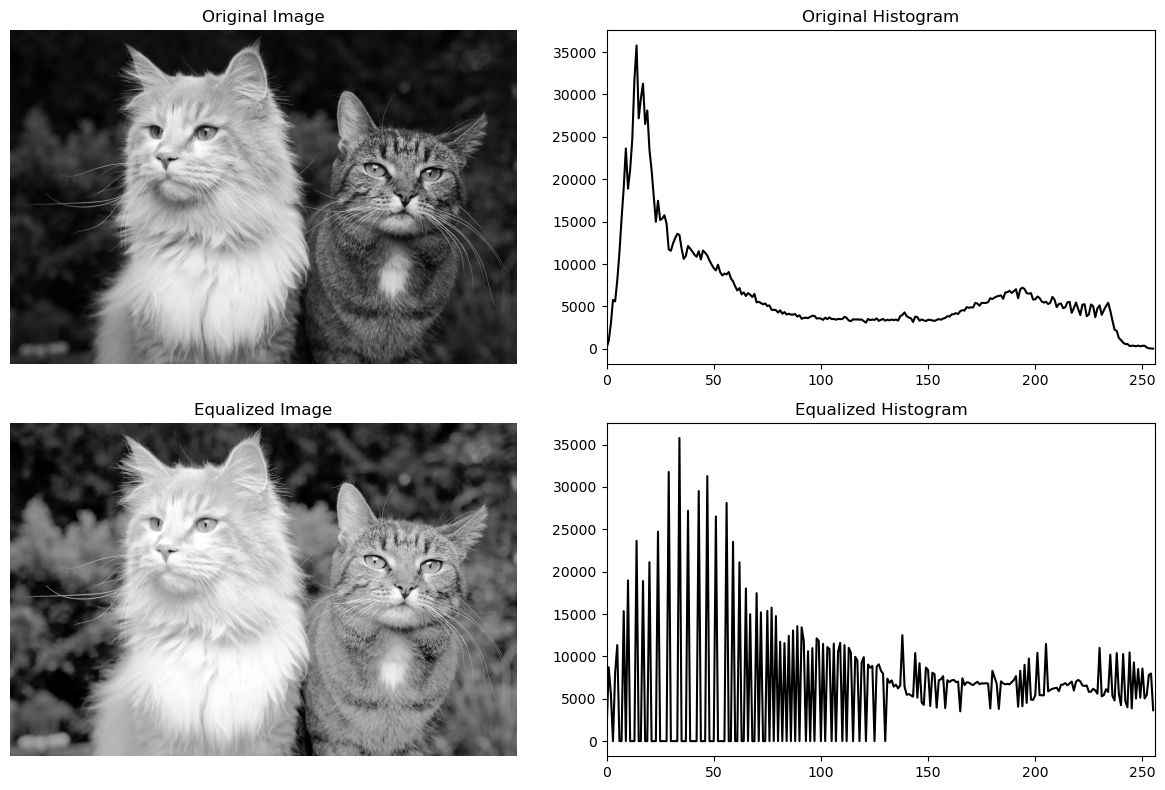

In [5]:
# Question 10 — Histogram and histogram equalization

equalized = cv2.equalizeHist(gray)

original_histogram = cv2.calcHist(
    [gray], [0], None, [256], [0, 256]
)

equalized_histogram = cv2.calcHist(
    [equalized], [0], None, [256], [0, 256]
)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.plot(original_histogram, color="black")
plt.title("Original Histogram")
plt.xlim([0, 256])

plt.subplot(2, 2, 3)
plt.imshow(equalized, cmap="gray")
plt.title("Equalized Image")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.plot(equalized_histogram, color="black")
plt.title("Equalized Histogram")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

In [ ]:
# Question 11 — Log and power-law (gamma) transformations